# Load functions and modules

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt

from pySEA.sea_eco.architecture.base_structure_numpy import Signal
from pySEA.sea_eco.models.components.gaussians import Gaussian1D


## Create a signal

Create a calibrated signal without shifts. Clone that dataset and apply shifts.

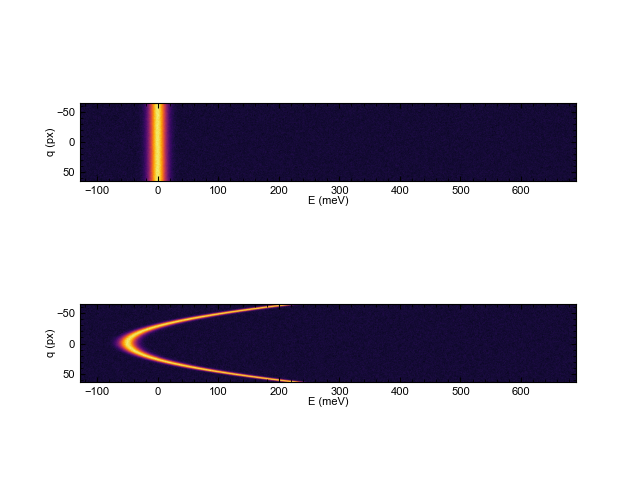

In [ ]:
dimensions= [{'name': 't', 'units': 'frame',  'size': 10,  'scale': 1.0, 'offset': 0, 'space':'temporal'},
             {'name': 'q', 'units': 'px',  'size': 129,  'scale': 1.0, 'offset': -64.5, 'space':'scattering'},
             {'name': 'E', 'units': 'meV', 'size': 1024, 'scale': 0.8, 'offset': -128., 'space':'spectral'}]
s1_2 = Signal(np.zeros((10,129,1024)), dimensions=dimensions)
s1_2.dimensions.nav_dimensions = [0]
s1_2.dimensions.nav_dimensions = [1,2]

s2_2 = s1_2.deepcopy()
x = s1_2.dimensions['t'].values
e = s1_2.dimensions['E'].values
q = s1_2.dimensions['q'].values
g = Gaussian1D(sigma=10)

shifts_in = 0.2
shifts_in = e-(1.3*q[:,None]*shifts_in)**2 + np.linspace(0,50,10)[:,None,None]

noise = np.random.normal(scale=1e-3, size=s1_2.data.shape)
s1_2.data = np.tile(g.evaluate(e)[None,...], (dimensions[0]['size'], dimensions[1]['size'],1)) + noise
s2_2.data = np.stack([g.evaluate(s) for s in shifts_in]) + noise

fig, axs = plt.subplots(nrows=2)
s1_2[0].show(ax=axs[0], ticks_and_labels='on', scale_bar=False)
s2_2[-1].show(ax=axs[1], ticks_and_labels='on', scale_bar=False)

# correlate_1D_in_ND

Find the correlation coefficient and manually find the realtive shift.<br />
The shift in pixels (px) is found by indexing the lag coresponding to the maximum correlation.
Note:
- The offset can be forward or backward one full spectral axis, so the correlation axis twice the size of the original axis.
- the signals can be cropped before correlation. e.g. `s2_2[...,-50.:400.].correlate_1D_in_ND(s1_2[...,-50.:400.], dims=-1)`

In [ ]:
s2_2.data.shape, s1_2.data.shape

1290it [00:00, 4704.06it/s]


sig: (10, 129, 1024)
coef: (10, 129, 2047)
shifts: (10, 129)


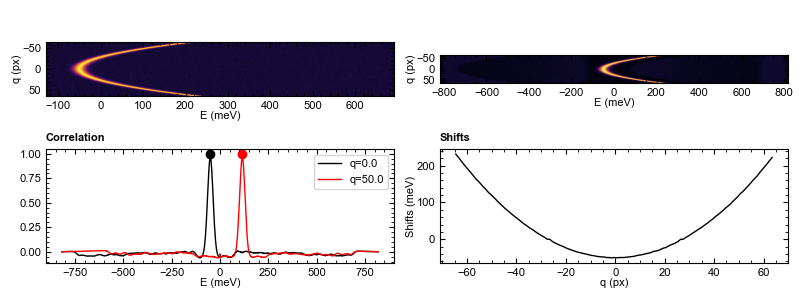

In [ ]:
# Perform correlation
coef = s2_2.correlate_1D_in_ND(s1_2, dims=-1)

print(f'sig: {s2_2.data.shape}')
print(f'coef: {coef.data.shape}')

# Manually find shifts
lags = coef.dimensions['E'].values
shifts = lags[np.argmax(coef, axis=-1)] #get the shift in pixels
print(f'shifts: {shifts.shape}')

# Plot
fig,axs = plt.subplots(figsize=(8,3), ncols=2, nrows=2)
axs = axs.flatten()

x = -1

s2_2[x].show(ax=axs[0], ticks_and_labels='on', scale_bar=False)
coef[x].show(ax=axs[1], ticks_and_labels='on', scale_bar=False)

axs[2].set_title('Correlation')
for v in [0.,50.]:
    coef[x,v].show(ax=axs[2], label=f'q={v}')
    s = shifts[x,coef.dimensions['q'].find_nearest_index(v)]
    axs[2].scatter(s, coef[x].data.max())
axs[2].legend()

axs[3].set_title('Shifts')
axs[3].plot(q, shifts[x])
axs[3].set_xlabel('q (px)')
axs[3].set_ylabel('Shifts (meV)')

fig.tight_layout()

We can also find the shifts automatically and allows for averaging of correlation axes prior to finding the shift index.

In [4]:
shifts = s2_2.get_shifts_correlate_1D_in_ND(s1_2, dims=-1, avg_corr_dims=(1))
print(f'shifts shape averaging dim=1: {shifts.data.shape}')

shifts = s2_2.get_shifts_correlate_1D_in_ND(s1_2, dims=-1)
print(f'shifts shape without averaging: {shifts.data.shape}')

1290it [00:00, 4581.53it/s]


shifts shape averaging dim=1: (10,)


1290it [00:00, 4493.93it/s]

shifts shape without averaging: (10, 129)


Apply the shifts

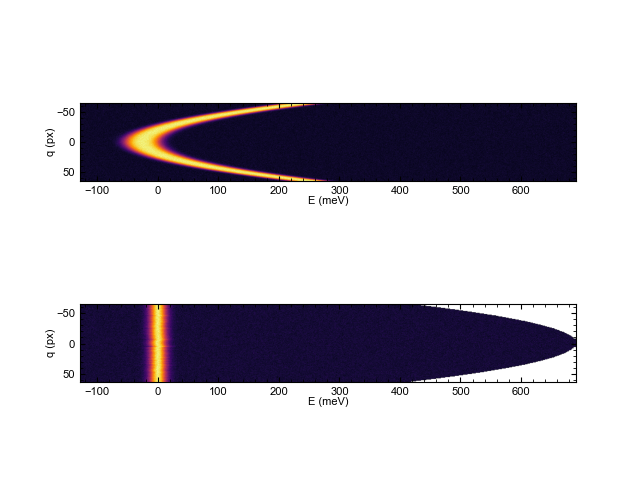

In [5]:
algnd = s2_2.shift(-shifts)

fig, axs = plt.subplots(nrows=2)
s2_2.show(ax=axs[0], ticks_and_labels='on', scale_bar=False)
algnd[0].show(ax=axs[1], ticks_and_labels='on', scale_bar=False)


# Autocorrelation

Find the autocorrelation coefficient and manually find the realtive shift.

100%|██████████| 9/9 [00:00<00:00, 35.06it/s]


array([[  0.,   0.],
       [  0.,  -5.],
       [  0., -10.],
       [  0., -15.],
       [  0., -20.],
       [  0., -25.],
       [  0., -30.],
       [  0., -35.],
       [  0., -40.],
       [  0., -45.]])

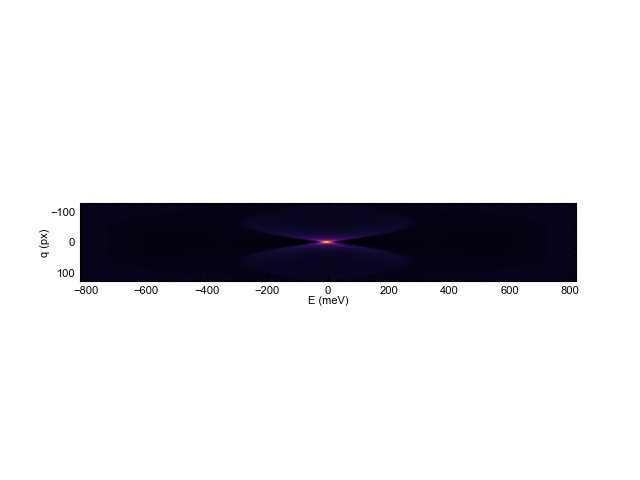

In [6]:
coef = s2_2.autocorrelate(dims=(-2,-1))
fig, ax = plt.subplots()
coef[-1].show(ax=ax, ticks_and_labels='on', scale_bar=False)


shifts = coef.maxND(dims=[-2,-1])[...,:-1]
shifts[0,:] = 0
shifts = np.cumsum(shifts, axis=0)
shifts
#maxND(corr, dims=dims_new)

We can also find the shifts automatically.

100%|██████████| 9/9 [00:00<00:00, 36.36it/s]

[[  0.   0.]
 [  0.  -5.]
 [  0. -10.]
 [  0. -15.]
 [  0. -20.]
 [  0. -25.]
 [  0. -30.]
 [  0. -35.]
 [  0. -40.]
 [  0. -45.]]


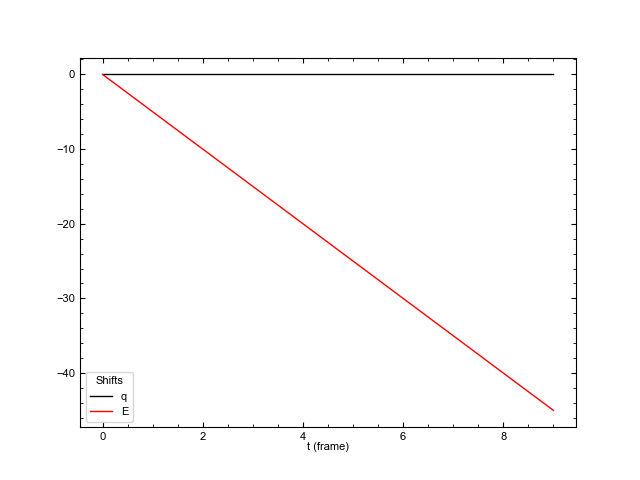

In [7]:
shifts = s2_2.get_shifts_autocorrelate(dims=(-2,-1))
print(shifts.data)

shifts_1 = shifts.deepcopy_with_new_data(shifts.data[...,0])
shifts_2 = shifts.deepcopy_with_new_data(shifts.data[...,1])

fig, ax = plt.subplots()
shifts_1.show(ax=ax, label='q')
shifts_2.show(ax=ax, label='E')
ax.legend(title='Shifts')

Apply the shifts

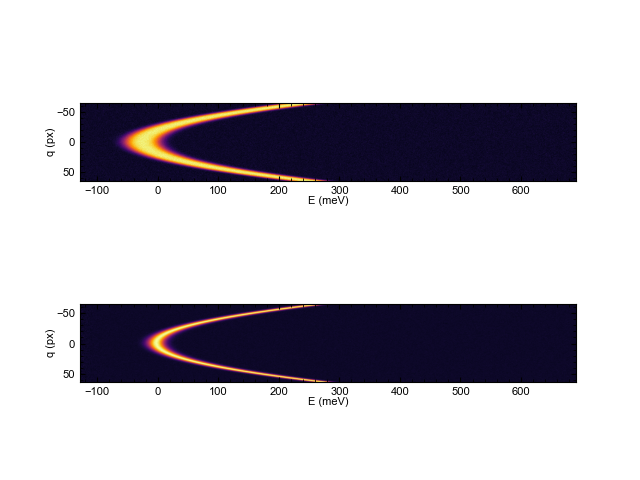

In [8]:
algnd = s2_2.shift(-shifts.data, dims=(-2,-1))

fig, axs = plt.subplots(nrows=2)
np.nanmean(s2_2, axis=0).show(ax=axs[0], ticks_and_labels='on', scale_bar=False)
np.nanmean(algnd, axis=0).show(ax=axs[1], ticks_and_labels='on', scale_bar=False)
